# Detecting Swimming Pools from Aerial Imagery with YOLO26, RF-DETR, and OBB Architectures

**Author:** Jan Wejchert  |  **Course:** Computer Vision Individual Assignment

---

## Project Introduction

This four-notebook project covers:

1. Auto-annotate a 288-image aerial dataset with GroundingDINO and review every annotation manually in Roboflow *(this notebook)*.
2. Fine-tune YOLO26 at four scales (nano, small, medium, large) with axis-aligned bounding boxes *(notebook 2)*.
3. Fine-tune RF-DETR at two scales (Nano, Small) and compare the transformer architecture against the YOLO baseline *(notebook 3)*.
4. Train YOLO26-OBB and YOLO11-OBB at two scales each (four oriented models total) and compare oriented vs axis-aligned localisation *(notebook 4)*.

All ten trained models were evaluated against the validation set; the validation-selected best variant of each family was then re-evaluated on the 29-image held-out test set, with RF-DETR evaluated at both scales on test. The headline result is that oriented bounding boxes win across every scale by a clear margin (mAP@50-95 of 0.737 vs 0.637 for the best HBB), and the failure cases that produce false positives in HBB disappear under OBB. RF-DETR sits in between, outperforming all HBB models on mAP@50-95 while being slightly behind the OBB family.

The cross-architecture synthesis, full results tables, required experimental analysis, and conclusion are collected at the end of notebook 4.

# Step 1: Auto-annotate Swimming Pools with Grounding DINO

Runs zero-shot detection over the 288 aerial images and exports YOLO-format labels for manual review.

**Runtime:** Colab → Runtime → Change runtime type → **T4 GPU** before running.

**Inputs you provide:** either mount Google Drive (and point at the dataset folder) **or** upload a zip of the `images/` directory.

**Outputs:** `pool_annotations.zip` containing `images/`, `labels/` (YOLO txt), `previews/` (visualisations), `classes.txt`, `low_confidence.csv`.

In [1]:
import torch
assert torch.cuda.is_available(), 'No GPU — switch runtime to T4 GPU and re-run.'
print(f'CUDA: {torch.cuda.get_device_name(0)}  |  torch {torch.__version__}')

CUDA: Tesla T4  |  torch 2.10.0+cu128


In [2]:
%pip install -q "transformers>=4.37,<5.0" rf-groundingdino supervision
print('Packages installed')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 123.4 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.2/93.2 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 49.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 28.8 MB/s eta 0:00:00
Packages installed


In [3]:
import urllib.request, pathlib
WEIGHTS_DIR = pathlib.Path.home() / 'weights'; WEIGHTS_DIR.mkdir(exist_ok=True)
CONFIG_PATH  = WEIGHTS_DIR / 'GroundingDINO_SwinT_OGC.py'
WEIGHTS_PATH = WEIGHTS_DIR / 'groundingdino_swint_ogc.pth'
for url, p in [('https://raw.githubusercontent.com/IDEA-Research/GroundingDINO/main/groundingdino/config/GroundingDINO_SwinT_OGC.py', CONFIG_PATH),
               ('https://github.com/IDEA-Research/GroundingDINO/releases/download/v0.1.0-alpha/groundingdino_swint_ogc.pth', WEIGHTS_PATH)]:
    if not p.exists():
        print(f'Downloading {p.name}...'); urllib.request.urlretrieve(url, p)
    else:
        print(f'{p.name} cached')
from groundingdino.util.inference import load_model
model = load_model(str(CONFIG_PATH), str(WEIGHTS_PATH))
print('Grounding DINO loaded')

final text_encoder_type: bert-base-uncased


Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Grounding DINO loaded


## Load images — choose ONE of the two cells below

**Option A** — mount Google Drive (recommended if the prof's drive folder is shared to your account).

In [4]:
# Option A: Google Drive
from google.colab import drive
drive.mount('/content/drive')

# EDIT this path to point at the folder containing the 288 PNG images:
DRIVE_IMAGES_DIR = '/content/drive/MyDrive/IE/IndividualAssignmentMBD2026/images'

import shutil, pathlib
IMAGES_DIR = pathlib.Path('/content/dataset/images'); IMAGES_DIR.mkdir(parents=True, exist_ok=True)
src = pathlib.Path(DRIVE_IMAGES_DIR)
assert src.exists(), f'Not found: {src}'
for f in src.iterdir():
    if f.suffix.lower() in {'.png', '.jpg', '.jpeg'}:
        shutil.copy(f, IMAGES_DIR / f.name)
print(f'{len(list(IMAGES_DIR.iterdir()))} images copied')

Mounted at /content/drive
288 images copied


In [5]:
# Option B: upload a zip of the images/ folder
# from google.colab import files
# import zipfile, pathlib
# uploaded = files.upload()  # pick images.zip
# IMAGES_DIR = pathlib.Path('/content/dataset/images'); IMAGES_DIR.mkdir(parents=True, exist_ok=True)
# zip_name = list(uploaded.keys())[0]
# with zipfile.ZipFile(zip_name) as z:
#     for member in z.namelist():
#         if member.lower().endswith(('.png', '.jpg', '.jpeg')) and not member.startswith('__'):
#             with z.open(member) as src, open(IMAGES_DIR / pathlib.Path(member).name, 'wb') as dst:
#                 dst.write(src.read())
# print(f'{len(list(IMAGES_DIR.iterdir()))} images extracted')

## Configuration

Single class `swimming pool`. Using a multi-phrase prompt to improve recall on dark pools, covered pools, and unusual shapes. Thresholds are tuned conservatively — we'd rather have some false positives to delete than miss real pools (manual review can only *remove*, not recover, missed detections... well, it can add them too, but that's slow).

In [6]:
CLASSES        = ['swimming pool']
TEXT_PROMPT    = 'swimming pool . pool . outdoor swimming pool .'
BOX_THRESHOLD  = 0.30
TEXT_THRESHOLD = 0.25
LOW_CONF_FLAG  = 0.40   # detections below this are flagged for priority review
print('Prompt:', TEXT_PROMPT)

Prompt: swimming pool . pool . outdoor swimming pool .


In [7]:
import pathlib, cv2, torch, numpy as np
from groundingdino.util.inference import load_image, predict
from torchvision.ops import box_convert
import supervision as sv
from tqdm import tqdm

IMAGES_DIR = pathlib.Path('/content/dataset/images')
LABELS_DIR = pathlib.Path('/content/dataset/labels'); LABELS_DIR.mkdir(parents=True, exist_ok=True)
PREVIEW_DIR = pathlib.Path('/content/dataset/previews'); PREVIEW_DIR.mkdir(parents=True, exist_ok=True)

image_paths = sorted([p for p in IMAGES_DIR.iterdir() if p.suffix.lower() in {'.png', '.jpg', '.jpeg'}])
print(f'{len(image_paths)} images to process')

box_ann   = sv.BoxAnnotator(thickness=2, color_lookup=sv.ColorLookup.INDEX)
label_ann = sv.LabelAnnotator(text_scale=0.4, text_padding=3, color_lookup=sv.ColorLookup.INDEX)

stats = []   # (image, n_det, max_conf, min_conf)
low_conf_rows = []

for img_path in tqdm(image_paths):
    image_source, image_tensor = load_image(str(img_path))
    h, w, _ = image_source.shape
    boxes, logits, phrases = predict(model=model, image=image_tensor, caption=TEXT_PROMPT,
                                     box_threshold=BOX_THRESHOLD, text_threshold=TEXT_THRESHOLD)
    if len(boxes):
        boxes_px = boxes * torch.tensor([w, h, w, h], dtype=torch.float32)
        xyxy = box_convert(boxes_px, in_fmt='cxcywh', out_fmt='xyxy').numpy()
        confs = logits.numpy()
    else:
        xyxy = np.zeros((0, 4)); confs = np.zeros((0,))

    # YOLO label: all detections collapsed to class 0 (swimming pool)
    label_path = LABELS_DIR / (img_path.stem + '.txt')
    with open(label_path, 'w') as f:
        for (x1, y1, x2, y2), conf in zip(xyxy, confs):
            cx = ((x1 + x2) / 2) / w; cy = ((y1 + y2) / 2) / h
            bw = (x2 - x1) / w; bh = (y2 - y1) / h
            f.write(f'0 {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}\n')
            if conf < LOW_CONF_FLAG:
                low_conf_rows.append((img_path.name, float(conf), cx, cy, bw, bh))

    # Preview
    if len(xyxy):
        det = sv.Detections(xyxy=xyxy, confidence=confs, class_id=np.zeros(len(xyxy), dtype=int))
        labels = [f'pool {c:.2f}' for c in confs]
        ann = box_ann.annotate(scene=image_source.copy(), detections=det)
        ann = label_ann.annotate(scene=ann, detections=det, labels=labels)
    else:
        ann = image_source.copy()
    cv2.imwrite(str(PREVIEW_DIR / (img_path.stem + '.jpg')), cv2.cvtColor(ann, cv2.COLOR_RGB2BGR))

    stats.append((img_path.name, len(xyxy), float(confs.max()) if len(confs) else 0.0,
                  float(confs.min()) if len(confs) else 0.0))

# classes file
with open('/content/dataset/classes.txt', 'w') as f:
    f.write('swimming pool\n')

# low-confidence CSV for priority review
import csv
with open('/content/dataset/low_confidence.csv', 'w', newline='') as f:
    w_ = csv.writer(f); w_.writerow(['image', 'confidence', 'cx', 'cy', 'w', 'h'])
    w_.writerows(sorted(low_conf_rows, key=lambda r: r[1]))

print(f'Done. Total detections: {sum(s[1] for s in stats)}  '
      f'| Images with 0 dets: {sum(1 for s in stats if s[1]==0)}  '
      f'| Low-confidence (< {LOW_CONF_FLAG}): {len(low_conf_rows)}')

288 images to process


100%|██████████| 288/288 [02:16<00:00,  2.11it/s]

Done. Total detections: 512  | Images with 0 dets: 20  | Low-confidence (< 0.4): 437


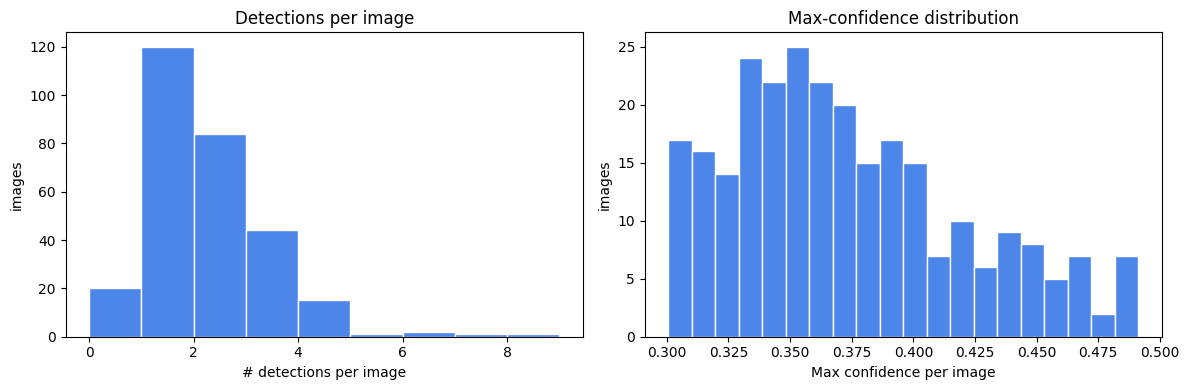

In [8]:
# Quick visual summary
import matplotlib.pyplot as plt
import numpy as np

all_conf = []
for s in stats:
    pass  # max/min recorded but per-detection confs not retained; rebuild from labels not needed for sanity plot

n_det = [s[1] for s in stats]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(n_det, bins=range(0, max(n_det)+2), color='#4C86E8', edgecolor='white')
axes[0].set_xlabel('# detections per image'); axes[0].set_ylabel('images')
axes[0].set_title('Detections per image')
axes[1].hist([s[2] for s in stats if s[1] > 0], bins=20, color='#4C86E8', edgecolor='white')
axes[1].set_xlabel('Max confidence per image'); axes[1].set_ylabel('images')
axes[1].set_title('Max-confidence distribution')
plt.tight_layout(); plt.show()

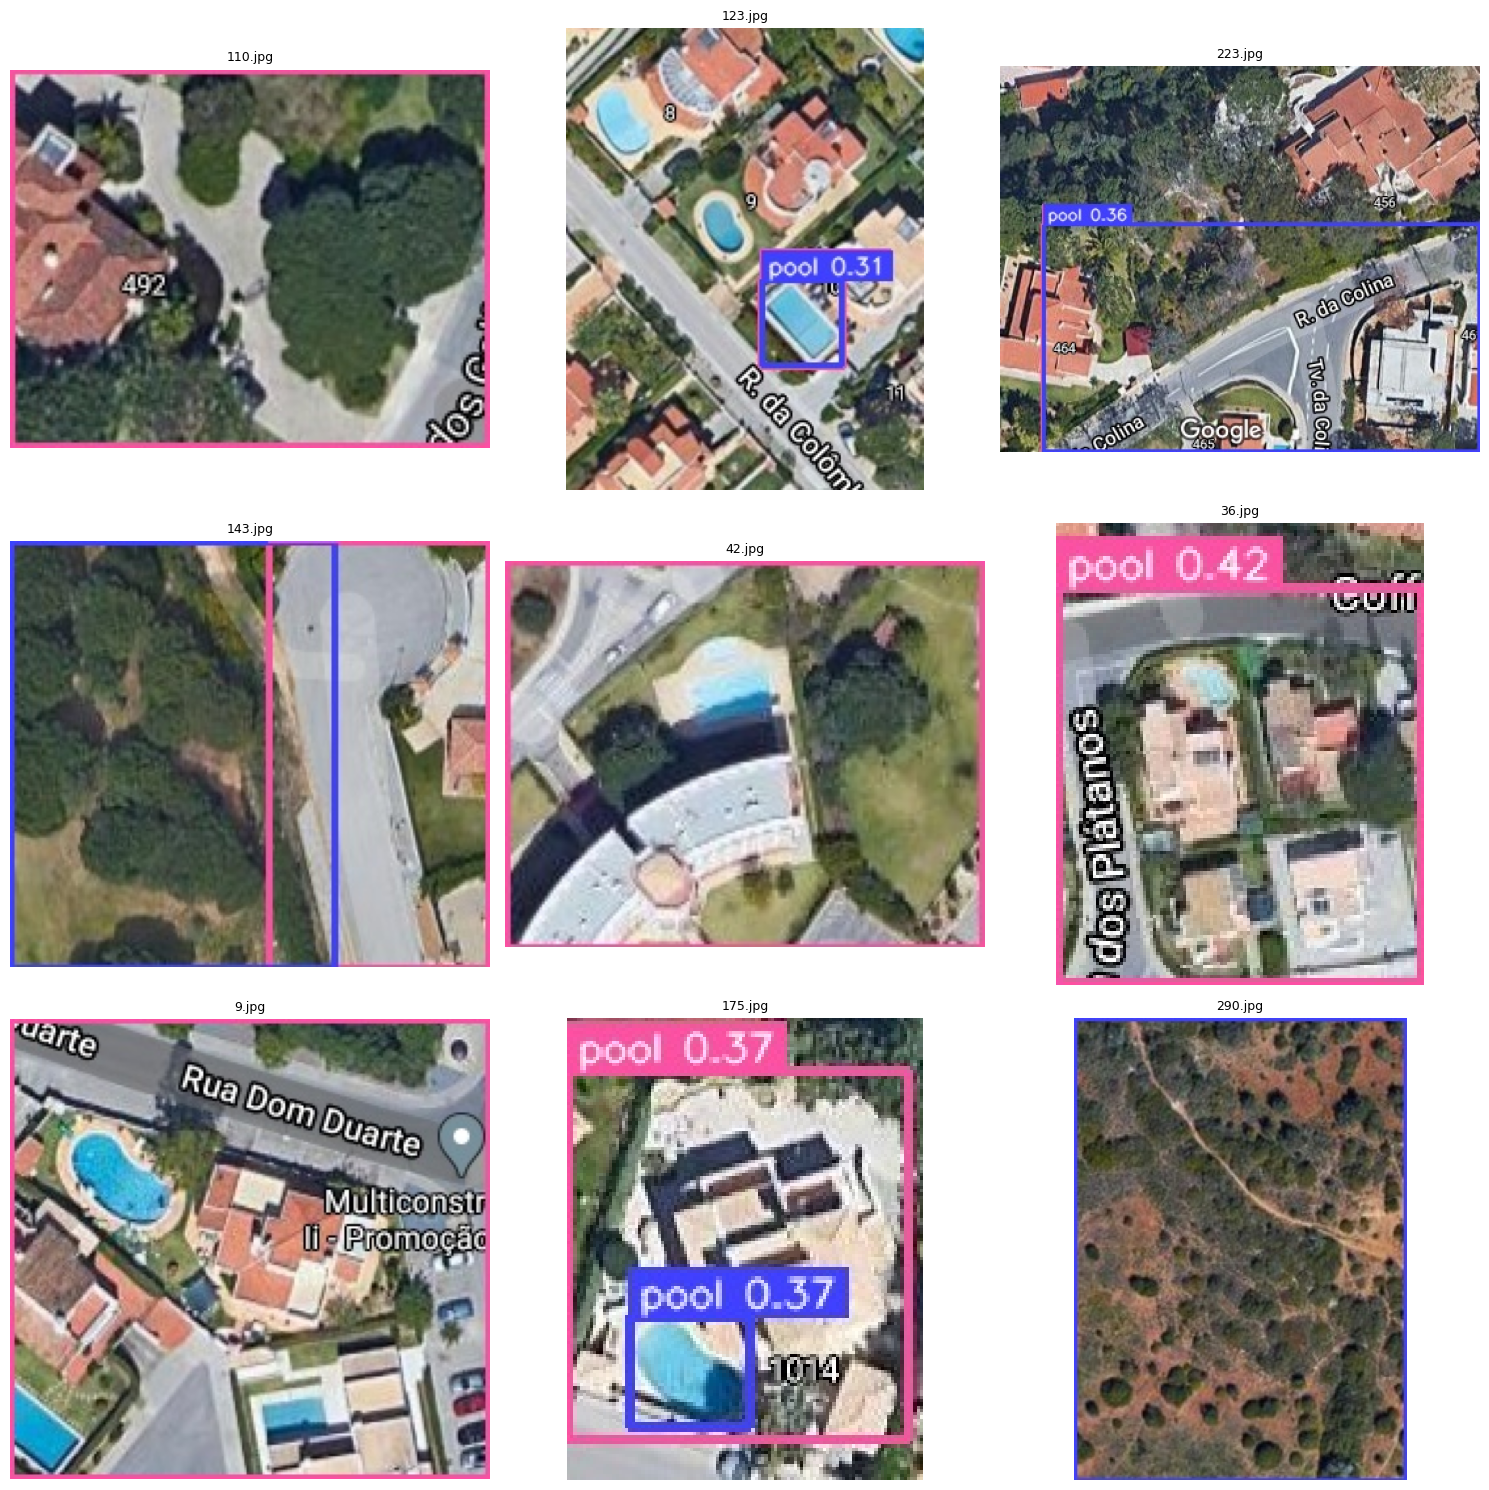

In [9]:
# Show a handful of previews — sanity check before downloading
import random, matplotlib.image as mpimg
sample = random.sample(list(PREVIEW_DIR.iterdir()), k=min(9, len(list(PREVIEW_DIR.iterdir()))))
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
for ax, p in zip(axes.flat, sample):
    ax.imshow(mpimg.imread(p)); ax.set_title(p.name, fontsize=9); ax.axis('off')
plt.tight_layout(); plt.show()

## Bundle for download

Zips images + labels + previews + classes + low-confidence CSV. Download from the Files sidebar or via the cell below.

In [10]:
import shutil
shutil.make_archive('/content/pool_annotations', 'zip', '/content/dataset')
print('Created /content/pool_annotations.zip')

from google.colab import files
files.download('/content/pool_annotations.zip')

Created /content/pool_annotations.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
import shutil
shutil.copy('/content/pool_annotations.zip',

'/content/drive/MyDrive/IE/IndividualAssignmentMBD2026/pool_annotations.zip')
print('Copied to Drive')

Copied to Drive


## Next: manual review

Unzip locally. Easiest review options:
1. **Roboflow** — upload images + YOLO labels, fix in the web UI, re-export YOLO. (Annotation-only use is allowed per the brief.)
2. **FiftyOne** — `pip install fiftyone`, load the YOLO dataset, fix in the desktop app.

Start with the rows in `low_confidence.csv` — those detections are the most likely to be wrong.

## Annotation Pipeline: manual review outcome

The 288 images were first auto-annotated with GroundingDINO (Swin-T backbone, prompt `swimming pool`, threshold 0.30). The threshold was set low enough to recover small or partially-shaded pools while keeping the manual-review queue tractable; it produced **512 raw detections across 268 images** (the run above). Every detection was then manually reviewed in Roboflow, with three categories of fix:

- **Remove false positives.** Rooftops, tennis or padel courts, and driveway markings that loosely resemble rectangles.
- **Add missed pools.** Smaller pools (under ~40 px) and pools partially hidden by tree canopy.
- **Trace polygons.** Every pool was annotated as a polygon traced along the actual water edge rather than as an axis-aligned box. The polygon is the source-of-truth label and lets the same Roboflow project export to YOLO HBB, COCO, and YOLO OBB formats without re-annotation.

After review the dataset settled at **364 verified pool polygons across 184 images**, with the remaining 36% of source images deliberately kept as backgrounds. Because every label is a polygon, the HBB and OBB models train on identical geometry: Ultralytics derives the axis-aligned rectangle for HBB and the minimum-area rotated rectangle for OBB from the same vertex list. This shared label is what makes the HBB-vs-OBB comparison fair, and it also explains why several HBB false positives are not detection failures but artifacts of fitting an axis-aligned box to a rotated polygon.

Reviewed dataset (Roboflow project `pools-tduhd`): https://universe.roboflow.com/jans-workspace-l9aj6/pools-tduhd/dataset/2

## Dataset and Splits

The dataset contains 288 aerial images of residential areas with a single class, `swimming pool`. Splits are 70 / 20 / 10 (train / validation / test), generated by Roboflow as a stratified random split (stratified on pool-vs-background presence so each split retains the same approximate 36% background rate).

| Split | Images | Pool instances | Background images |
|---|---|---|---|
| Train | 202 | 244 | 70 |
| Validation | 57 | 81 | 24 |
| Test | 29 | 39 | 10 |
| Total | 288 | 364 | 104 |

The 70 / 20 / 10 ratio is a deliberate choice for a small dataset. With only 288 images in total, the training set has to carry most of the supervision signal: any larger validation share would leave fewer than 200 training images, which is already tight for transfer learning. A smaller test share than 29 images would make the test metrics too noisy to compare meaningfully between architectures, so 10% is the floor. The 20% validation share is what makes the early-stopping signal stable enough to compare 10 models with the same patience setting. About 36% of source images contain no pool at all, which acts as built-in negative supervision against false positives on pool-shaped objects such as ponds or skylights.

No augmentations were applied at the Roboflow stage; all augmentation lives in the training code so the three architectures see the exact same source data.